# Deep Q-Network (DQN) — Lunar Lander

Implementação do algoritmo DQN do zero aplicado ao ambiente `LunarLander-v3` do Gymnasium.
O notebook cobre: exploração do ambiente, implementação dos componentes do DQN (QNetwork, ReplayBuffer, DQNAgent),
loop de treinamento com erro de Bellman, e análise comparativa de três configurações.

## Imports e Configuração Inicial

In [4]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
print('gymnasium:', gym.__version__)
print('torch:', torch.__version__)

gymnasium: 1.3.0
torch: 2.3.1+cu121


### Seed Global e Dispositivo

A seed é fixada em todas as fontes de aleatoriedade para garantir reprodutibilidade completa.
Sem isso, diferentes execuções produzem curvas distintas, impossibilitando comparações válidas entre configurações.

In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'Seed: {SEED}')

Device: cuda
Seed: 42


## Exploração do Ambiente

Antes de implementar o agente, inspecionamos o espaço de estados e ações do LunarLander.

In [7]:
# verifica qual versao do LunarLander esta disponivel
try:
    _test_env = gym.make('LunarLander-v3')
    _test_env.close()
    ENV_NAME = 'LunarLander-v3'
except Exception:
    try:
        _test_env = gym.make('LunarLander-v2')
        _test_env.close()
        ENV_NAME = 'LunarLander-v2'
    except Exception as _e:
        raise RuntimeError(
            "Box2D nao encontrado. Execute: pip install swig && pip install 'gymnasium[box2d]'"
        ) from _e

print(f'Ambiente: {ENV_NAME}')

env_explore = gym.make(ENV_NAME)
print(f'Observation space: {env_explore.observation_space}')
print(f'Action space:      {env_explore.action_space}')

obs, _ = env_explore.reset(seed=SEED)
print(f'\nExemplo de estado inicial:')
labels = ['pos_x', 'pos_y', 'vel_x', 'vel_y', 'angulo', 'vel_angular', 'perna_esq', 'perna_dir']
for i, (label, val) in enumerate(zip(labels, obs)):
    print(f'  [{i}] {label:14s} = {val:.4f}')

env_explore.close()

STATE_DIM = 8
ACTION_DIM = 4
print(f'\nSTATE_DIM  = {STATE_DIM}')
print(f'ACTION_DIM = {ACTION_DIM}')

Ambiente: LunarLander-v3
Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space:      Discrete(4)

Exemplo de estado inicial:
  [0] pos_x          = 0.0023
  [1] pos_y          = 1.4181
  [2] vel_x          = 0.2326
  [3] vel_y          = 0.3205
  [4] angulo         = -0.0027
  [5] vel_angular    = -0.0527
  [6] perna_esq      = 0.0000
  [7] perna_dir      = 0.0000

STATE_DIM  = 8
ACTION_DIM = 4


## Rede Neural Q (QNetwork)

Arquitetura MLP com:
- **Entrada: 8 neurônios** — coerente com o vetor de estado do LunarLander
- **2 camadas ocultas: 256 neurônios + ReLU** — capacidade suficiente sem overfitting; ReLU evita vanishing gradient
- **Saída: 4 neurônios lineares** — um Q-valor por ação; sem ativação final pois Q-valores são reais arbitrários

A seed é passada ao construtor para que pesos iniciais sejam idênticos entre experimentos.

In [8]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, seed=SEED):
        super().__init__()
        torch.manual_seed(seed)
        self.fc1 = nn.Linear(state_dim, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, action_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)


# verificacao das dimensoes
_net = QNetwork(STATE_DIM, ACTION_DIM)
_dummy = torch.zeros(1, STATE_DIM)
_out = _net(_dummy)
print(f'Input shape:  {_dummy.shape}')
print(f'Output shape: {_out.shape}')
total_params = sum(p.numel() for p in _net.parameters())
print(f'Total params: {total_params:,}')
del _net, _dummy, _out

Input shape:  torch.Size([1, 8])
Output shape: torch.Size([1, 4])
Total params: 69,124


## Replay Buffer (Experience Replay)

Armazena transições `(s, a, r, s', done)` em um deque de capacidade fixa e amostra mini-batches aleatórios.
Quebra a correlação temporal das transições sequenciais, estabilizando o gradiente durante o treinamento.

**Sem replay buffer**: o agente treina em dados altamente correlacionados, leva ao catastrophic forgetting e instabilidade.

In [9]:
class ReplayBuffer:
    def __init__(self, capacity, seed=SEED):
        self.buffer = deque(maxlen=capacity)
        self.rng = np.random.default_rng(seed)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((
            np.array(state, dtype=np.float32),
            int(action),
            float(reward),
            np.array(next_state, dtype=np.float32),
            float(done)
        ))

    def sample(self, batch_size):
        indices = self.rng.choice(len(self.buffer), batch_size, replace=False)
        batch = [self.buffer[i] for i in indices]
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.stack(states),
            np.array(actions, dtype=np.int64),
            np.array(rewards, dtype=np.float32),
            np.stack(next_states),
            np.array(dones, dtype=np.float32)
        )

    def __len__(self):
        return len(self.buffer)

## Agente DQN

O agente encapsula:
1. **Rede online** (`online_net`): atualizada a cada passo pelo gradiente
2. **Target network** (`target_net`): cópia congelada atualizada a cada N episódios — estabiliza o alvo Bellman
3. **Política epsilon-greedy**: exploração decrescente ao longo do treinamento
4. **Loss function**: erro quadrático do erro de Bellman (MSE do TD error)

O flag `use_target` e `use_replay` permite ablações controladas para os experimentos comparativos.

In [10]:
class DQNAgent:
    def __init__(self, state_dim, action_dim, config, seed=SEED):
        self.action_dim = action_dim
        self.gamma = config['gamma']
        self.batch_size = config['batch_size']
        self.epsilon = config['epsilon_start']
        self.epsilon_min = config['epsilon_min']
        self.epsilon_decay = config['epsilon_decay']
        self.target_update_freq = config.get('target_update_freq', 10)
        self.use_replay = config.get('use_replay', True)
        self.use_target = config.get('use_target', True)
        self.steps = 0
        self._rng = random.Random(seed)

        self.online_net = QNetwork(state_dim, action_dim, seed).to(DEVICE)

        if self.use_target:
            self.target_net = QNetwork(state_dim, action_dim, seed).to(DEVICE)
            self.target_net.load_state_dict(self.online_net.state_dict())
            for param in self.target_net.parameters():
                param.requires_grad = False

        self.optimizer = optim.Adam(self.online_net.parameters(), lr=config['lr'])
        self.loss_fn = nn.MSELoss()

        if self.use_replay:
            self.memory = ReplayBuffer(config['buffer_size'], seed)

    def select_action(self, state, training=True):
        # epsilon-greedy: explora aleatoriamente com probabilidade epsilon
        if training and self._rng.random() < self.epsilon:
            return self._rng.randrange(self.action_dim)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
            q_values = self.online_net(state_t)
        return int(q_values.argmax(1).item())

    def _bellman_loss(self, states, actions, rewards, next_states, dones):
        states_t = torch.FloatTensor(states).to(DEVICE)
        actions_t = torch.LongTensor(actions).to(DEVICE)
        rewards_t = torch.FloatTensor(rewards).to(DEVICE)
        next_states_t = torch.FloatTensor(next_states).to(DEVICE)
        dones_t = torch.FloatTensor(dones).to(DEVICE)

        # Q(s, a) — apenas para as acoes que foram realmente tomadas
        current_q = self.online_net(states_t).gather(1, actions_t.unsqueeze(1)).squeeze(1)

        # alvo Bellman: r + gamma * max_a' Q_target(s', a') * (1 - done)
        # torch.no_grad() garante que o alvo nao gere gradientes
        with torch.no_grad():
            if self.use_target:
                next_q = self.target_net(next_states_t).max(1)[0]
            else:
                # sem target network: usa a propria rede online como alvo (alvo em movimento)
                next_q = self.online_net(next_states_t).max(1)[0]
            target_q = rewards_t + self.gamma * next_q * (1.0 - dones_t)

        # erro de Bellman ao quadrado (MSE do TD error)
        return self.loss_fn(current_q, target_q)

    def train_step(self, state, action, reward, next_state, terminated):
        if self.use_replay:
            self.memory.push(state, action, reward, next_state, terminated)
            if len(self.memory) < self.batch_size:
                return None
            batch = self.memory.sample(self.batch_size)
        else:
            # sem replay: treina diretamente na transicao atual (dados correlacionados)
            batch = (
                np.array([state], dtype=np.float32),
                np.array([action], dtype=np.int64),
                np.array([reward], dtype=np.float32),
                np.array([next_state], dtype=np.float32),
                np.array([float(terminated)], dtype=np.float32)
            )

        loss = self._bellman_loss(*batch)

        self.optimizer.zero_grad()
        loss.backward()
        # gradient clipping previne explosao de gradientes
        torch.nn.utils.clip_grad_norm_(self.online_net.parameters(), 1.0)
        self.optimizer.step()

        self.steps += 1
        return loss.item()

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def update_target(self):
        if self.use_target:
            self.target_net.load_state_dict(self.online_net.state_dict())

## Loop de Treinamento

A função `run_experiment` executa o loop completo DQN:
1. Coleta uma transição `(s, a, r, s', terminated)` por passo
2. Chama `train_step` para atualizar os pesos via gradiente do erro de Bellman
3. Decai epsilon após cada episódio
4. Atualiza a target network a cada `target_update_freq` episódios
5. Para antecipadamente se a média de 100 episódios atingir 200 pontos

Nota: usa `terminated` (não `done`) no cálculo do alvo Bellman. Episódios truncados por timeout
ainda têm valor futuro; só episódios terminados fisicamente (crash/pouso) têm valor futuro zero.

In [11]:
def run_experiment(config, exp_name, num_episodes=700, seed=SEED):
    env = gym.make(ENV_NAME)
    agent = DQNAgent(STATE_DIM, ACTION_DIM, config, seed)

    episode_rewards = []
    moving_avgs = []

    for ep in range(num_episodes):
        # seed por episodio: reproducivel mas variado entre episodios
        state, _ = env.reset(seed=seed + ep)
        total_reward = 0.0
        done = False

        while not done:
            action = agent.select_action(state, training=True)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # passa terminated (nao done) para o calculo correto do alvo Bellman
            agent.train_step(state, action, reward, next_state, terminated)
            state = next_state
            total_reward += reward

        agent.decay_epsilon()

        if agent.use_target and (ep + 1) % config['target_update_freq'] == 0:
            agent.update_target()

        episode_rewards.append(total_reward)
        avg = np.mean(episode_rewards[-100:])
        moving_avgs.append(avg)

        if (ep + 1) % 50 == 0:
            print(f'[{exp_name}] Ep {ep+1:4d}/{num_episodes} | '
                  f'Reward: {total_reward:8.1f} | '
                  f'Avg(100): {avg:7.1f} | '
                  f'eps: {agent.epsilon:.3f}')

        if avg >= 200 and len(episode_rewards) >= 100:
            print(f'\n*** [{exp_name}] Resolvido no episodio {ep + 1}! Avg(100) = {avg:.1f} ***\n')
            break

    env.close()
    return episode_rewards, moving_avgs, agent

## Configurações dos Experimentos

Hiperparâmetros base compartilhados pelos três experimentos:

| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| gamma | 0.99 | Desconto alto para problema de horizonte longo |
| lr | 5e-4 | Adam com lr moderado; lr maior causa oscilações |
| epsilon_start | 1.0 | Exploração total no início |
| epsilon_min | 0.01 | Mantém 1% de exploração residual |
| epsilon_decay | 0.995 | Epsilon ≈ 0.07 após 500 episódios |
| batch_size | 64 | Equilíbrio entre estabilidade e custo computacional |
| buffer_size | 50000 | Diversidade suficiente sem memória excessiva |
| target_update_freq | 10 | Atualiza target a cada 10 episódios |

In [12]:
BASE_CONFIG = {
    'gamma': 0.99,
    'lr': 5e-4,
    'epsilon_start': 1.0,
    'epsilon_min': 0.01,
    'epsilon_decay': 0.995,
    'batch_size': 64,
    'buffer_size': 50000,
    'target_update_freq': 10,
    'use_replay': True,
    'use_target': True,
}

NUM_EPISODES = 700

## Experimento 1: DQN Completo

Algoritmo DQN original com experience replay e target network.
Esta é a baseline de referência — esperamos convergência estável para média ≥ 200.

In [13]:
config_full = {**BASE_CONFIG, 'use_replay': True, 'use_target': True}

print('=' * 65)
print('Experimento 1: DQN Completo (Experience Replay + Target Network)')
print('=' * 65)

rewards_full, avgs_full, agent_full = run_experiment(
    config_full, 'DQN Completo', num_episodes=NUM_EPISODES, seed=SEED
)

print(f'\nResultado final — Avg(100) ultimos episodios: {np.mean(rewards_full[-100:]):.1f}')

Experimento 1: DQN Completo (Experience Replay + Target Network)
[DQN Completo] Ep   50/700 | Reward:   -123.7 | Avg(100):  -142.3 | eps: 0.778
[DQN Completo] Ep  100/700 | Reward:   -260.3 | Avg(100):  -118.3 | eps: 0.606
[DQN Completo] Ep  150/700 | Reward:     76.0 | Avg(100):   -73.5 | eps: 0.471
[DQN Completo] Ep  200/700 | Reward:    -11.0 | Avg(100):   -17.6 | eps: 0.367
[DQN Completo] Ep  250/700 | Reward:     60.0 | Avg(100):    35.1 | eps: 0.286
[DQN Completo] Ep  300/700 | Reward:    200.0 | Avg(100):    56.9 | eps: 0.222
[DQN Completo] Ep  350/700 | Reward:   -177.3 | Avg(100):    70.0 | eps: 0.173
[DQN Completo] Ep  400/700 | Reward:    239.3 | Avg(100):    93.5 | eps: 0.135
[DQN Completo] Ep  450/700 | Reward:    -51.4 | Avg(100):   117.5 | eps: 0.105
[DQN Completo] Ep  500/700 | Reward:   -135.2 | Avg(100):   154.3 | eps: 0.082
[DQN Completo] Ep  550/700 | Reward:    240.0 | Avg(100):   189.6 | eps: 0.063
[DQN Completo] Ep  600/700 | Reward:    226.6 | Avg(100):   193.0 

## Experimento 2: DQN sem Target Network

Ablação: a rede online é usada diretamente como alvo Bellman, sem cópia congelada.
O alvo muda a cada passo junto com os pesos, criando um "moving target" instável.
Esperamos maior variância e oscilações mais pronunciadas.

In [14]:
config_no_target = {**BASE_CONFIG, 'use_replay': True, 'use_target': False}

print('=' * 65)
print('Experimento 2: DQN sem Target Network')
print('=' * 65)

rewards_no_target, avgs_no_target, agent_no_target = run_experiment(
    config_no_target, 'Sem Target Net', num_episodes=NUM_EPISODES, seed=SEED
)

print(f'\nResultado final — Avg(100) ultimos episodios: {np.mean(rewards_no_target[-100:]):.1f}')

Experimento 2: DQN sem Target Network
[Sem Target Net] Ep   50/700 | Reward:    -99.3 | Avg(100):  -133.2 | eps: 0.778
[Sem Target Net] Ep  100/700 | Reward:    -87.6 | Avg(100):  -113.7 | eps: 0.606
[Sem Target Net] Ep  150/700 | Reward:   -273.3 | Avg(100):   -78.9 | eps: 0.471
[Sem Target Net] Ep  200/700 | Reward:     13.5 | Avg(100):   -41.7 | eps: 0.367
[Sem Target Net] Ep  250/700 | Reward:     -2.8 | Avg(100):     9.8 | eps: 0.286
[Sem Target Net] Ep  300/700 | Reward:    -56.3 | Avg(100):    42.4 | eps: 0.222
[Sem Target Net] Ep  350/700 | Reward:     25.4 | Avg(100):    47.3 | eps: 0.173
[Sem Target Net] Ep  400/700 | Reward:    157.7 | Avg(100):    77.7 | eps: 0.135
[Sem Target Net] Ep  450/700 | Reward:    135.3 | Avg(100):    96.7 | eps: 0.105
[Sem Target Net] Ep  500/700 | Reward:   -166.1 | Avg(100):   113.5 | eps: 0.082
[Sem Target Net] Ep  550/700 | Reward:    246.1 | Avg(100):   177.6 | eps: 0.063

*** [Sem Target Net] Resolvido no episodio 571! Avg(100) = 200.2 ***



## Experimento 3: DQN sem Experience Replay

Ablação: sem buffer de memória, o agente treina em cada transição individualmente e de forma sequencial.
Transições consecutivas são altamente correlacionadas, levando a catastrophic forgetting.
Esperamos convergência muito mais lenta ou ausente.

In [15]:
config_no_replay = {**BASE_CONFIG, 'use_replay': False, 'use_target': True, 'batch_size': 1}

print('=' * 65)
print('Experimento 3: DQN sem Experience Replay')
print('=' * 65)

rewards_no_replay, avgs_no_replay, agent_no_replay = run_experiment(
    config_no_replay, 'Sem Replay', num_episodes=NUM_EPISODES, seed=SEED
)

print(f'\nResultado final — Avg(100) ultimos episodios: {np.mean(rewards_no_replay[-100:]):.1f}')

Experimento 3: DQN sem Experience Replay
[Sem Replay] Ep   50/700 | Reward:   -319.3 | Avg(100):  -177.0 | eps: 0.778
[Sem Replay] Ep  100/700 | Reward:   -111.5 | Avg(100):  -147.2 | eps: 0.606
[Sem Replay] Ep  150/700 | Reward:    -70.9 | Avg(100):   -95.3 | eps: 0.471
[Sem Replay] Ep  200/700 | Reward:     67.3 | Avg(100):   -70.6 | eps: 0.367
[Sem Replay] Ep  250/700 | Reward:   -143.2 | Avg(100):   -58.2 | eps: 0.286
[Sem Replay] Ep  300/700 | Reward:    -66.5 | Avg(100):   -50.5 | eps: 0.222
[Sem Replay] Ep  350/700 | Reward:   -208.9 | Avg(100):   -67.1 | eps: 0.173
[Sem Replay] Ep  400/700 | Reward:   -125.3 | Avg(100):   -79.4 | eps: 0.135
[Sem Replay] Ep  450/700 | Reward:   -125.7 | Avg(100):  -107.2 | eps: 0.105
[Sem Replay] Ep  500/700 | Reward:   -117.6 | Avg(100):  -122.6 | eps: 0.082
[Sem Replay] Ep  550/700 | Reward:   -143.6 | Avg(100):  -111.5 | eps: 0.063
[Sem Replay] Ep  600/700 | Reward:    -59.1 | Avg(100):  -111.0 | eps: 0.049
[Sem Replay] Ep  650/700 | Reward: 

## Comparação e Curvas de Aprendizado

Dois gráficos:
1. **Recompensa bruta por episódio** (com transparência para visualizar variância)
2. **Média móvel de 100 episódios** (suaviza oscilações e mostra tendência de convergência)

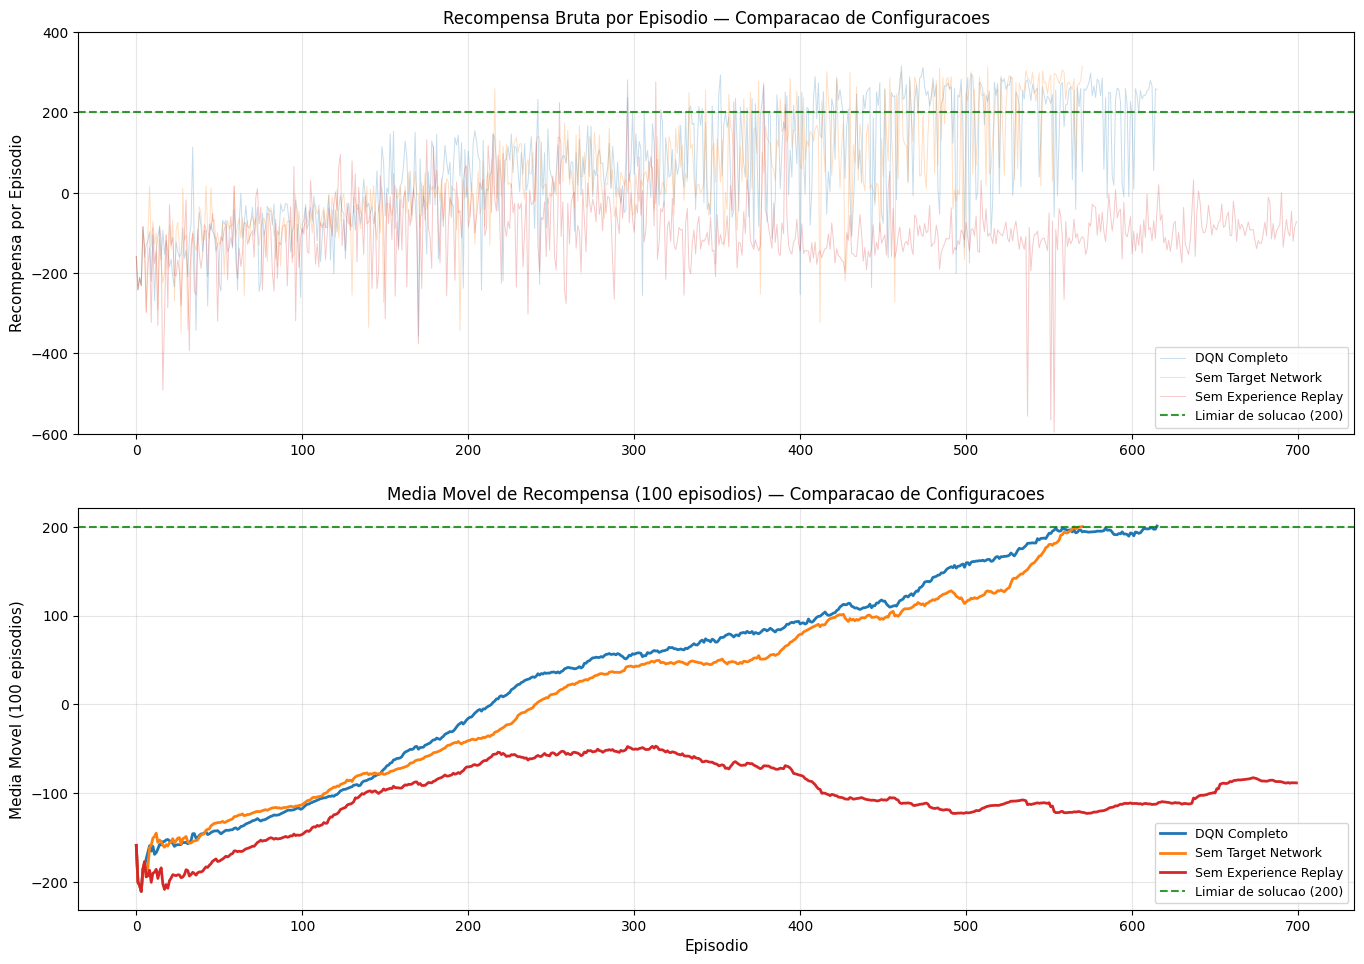

Grafico salvo: comparacao_configuracoes.png


In [16]:
COLORS = {'full': '#1f77b4', 'no_target': '#ff7f0e', 'no_replay': '#d62728'}
NAMES = ['DQN Completo', 'Sem Target Network', 'Sem Experience Replay']

all_rewards = [rewards_full, rewards_no_target, rewards_no_replay]
all_avgs = [avgs_full, avgs_no_target, avgs_no_replay]
colors_list = list(COLORS.values())

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# grafico 1: recompensa bruta por episodio
ax1 = axes[0]
for rewards, name, color in zip(all_rewards, NAMES, colors_list):
    ax1.plot(rewards, alpha=0.25, color=color, linewidth=0.7, label=name)
ax1.axhline(y=200, color='green', linestyle='--', linewidth=1.5, alpha=0.8, label='Limiar de solucao (200)')
ax1.set_ylabel('Recompensa por Episodio', fontsize=11)
ax1.set_title('Recompensa Bruta por Episodio — Comparacao de Configuracoes', fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-600, 400)

# grafico 2: media movel de 100 episodios
ax2 = axes[1]
for avgs, name, color in zip(all_avgs, NAMES, colors_list):
    ax2.plot(avgs, color=color, linewidth=2.0, label=name)
ax2.axhline(y=200, color='green', linestyle='--', linewidth=1.5, alpha=0.8, label='Limiar de solucao (200)')
ax2.set_xlabel('Episodio', fontsize=11)
ax2.set_ylabel('Media Movel (100 episodios)', fontsize=11)
ax2.set_title('Media Movel de Recompensa (100 episodios) — Comparacao de Configuracoes', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout(pad=2.0)
plt.savefig('comparacao_configuracoes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico salvo: comparacao_configuracoes.png')

## Tabela de Resultados

In [17]:
print(f'\n{"Configuracao":<30} {"Avg(100) Final":>16} {"Recompensa Max":>16} {"Episodios":>12}')
print('-' * 78)

for name, rewards in zip(NAMES, all_rewards):
    final_avg = np.mean(rewards[-100:]) if len(rewards) >= 100 else np.mean(rewards)
    max_r = max(rewards)
    solved = '(RESOLVIDO)' if final_avg >= 200 else ''
    print(f'{name:<30} {final_avg:>16.1f} {max_r:>16.1f} {len(rewards):>12}  {solved}')

print()


Configuracao                     Avg(100) Final   Recompensa Max    Episodios
------------------------------------------------------------------------------
DQN Completo                              200.8            315.1          616  (RESOLVIDO)
Sem Target Network                        200.2            314.3          571  (RESOLVIDO)
Sem Experience Replay                     -88.5            275.1          700  



## Salvando o Modelo Treinado

In [18]:
torch.save({
    'model_state_dict': agent_full.online_net.state_dict(),
    'config': config_full,
    'seed': SEED,
    'final_avg': float(np.mean(rewards_full[-100:])),
    'episodes_trained': len(rewards_full),
}, 'dqn_lunarlander_full.pth')

print('Modelo DQN Completo salvo em: dqn_lunarlander_full.pth')

# verificacao: carrega e testa o modelo salvo
checkpoint = torch.load('dqn_lunarlander_full.pth', map_location=DEVICE, weights_only=False)
print(f'Checkpoint carregado com sucesso.')
print(f'  Episodios treinados: {checkpoint["episodes_trained"]}')
print(f'  Avg(100) final:      {checkpoint["final_avg"]:.1f}')
print(f'  Seed:                {checkpoint["seed"]}')

Modelo DQN Completo salvo em: dqn_lunarlander_full.pth
Checkpoint carregado com sucesso.
  Episodios treinados: 616
  Avg(100) final:      200.8
  Seed:                42


## Avaliação do Agente Treinado (sem exploração)

Roda 10 episódios com epsilon=0 para verificar o comportamento da política aprendida.

In [19]:
def evaluate_agent(agent, n_episodes=10, seed=SEED + 10000):
    env = gym.make(ENV_NAME)
    eval_rewards = []

    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed + ep)
        total_reward = 0.0
        done = False

        while not done:
            action = agent.select_action(state, training=False)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward

        eval_rewards.append(total_reward)
        print(f'  Episodio {ep+1:2d}: {total_reward:7.1f}')

    env.close()
    print(f'\n  Media: {np.mean(eval_rewards):.1f} | Desvio: {np.std(eval_rewards):.1f}')
    return eval_rewards


print('Avaliacao do DQN Completo (epsilon = 0):')
eval_rewards = evaluate_agent(agent_full, n_episodes=10)

Avaliacao do DQN Completo (epsilon = 0):
  Episodio  1:   283.0
  Episodio  2:   267.8
  Episodio  3:   129.6
  Episodio  4:   -16.0
  Episodio  5:   261.4
  Episodio  6:   275.7
  Episodio  7:   254.0
  Episodio  8:  -115.6
  Episodio  9:   296.7
  Episodio 10:   303.1

  Media: 194.0 | Desvio: 139.5
